In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!pip install nltk -q

In [5]:
import re
import pandas as pd
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

# Download required NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("All imports and downloads successful!")

All imports and downloads successful!


In [6]:
DATA_PATH = "/content/drive/MyDrive/AI and Machine Learning/trum_tweet_sentiment_analysis.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
print(f"Columns      : {df.columns.tolist()}")
df.head()

Dataset shape: (1850123, 2)
Columns      : ['text', 'Sentiment']


,text,Sentiment
0,RT @JohnLeguizamo: #trump not draining swamp b...,0
1,ICYMI: Hackers Rig FM Radio Stations To Play A...,0
2,Trump protests: LGBTQ rally in New York https:...,1
3,"""Hi I'm Piers Morgan. David Beckham is awful b...",0
4,RT @GlennFranco68: Tech Firm Suing BuzzFeed fo...,0


In [8]:
print(df.columns.tolist())
print(df.head(3))

['text', 'Sentiment']
                                                text  Sentiment
0  RT @JohnLeguizamo: #trump not draining swamp b...          0
1  ICYMI: Hackers Rig FM Radio Stations To Play A...          0
2  Trump protests: LGBTQ rally in New York https:...          1


Label distribution:
Sentiment
0    1244211
1     605912
Name: count, dtype: int64

Missing values:
text         0
Sentiment    0
dtype: int64


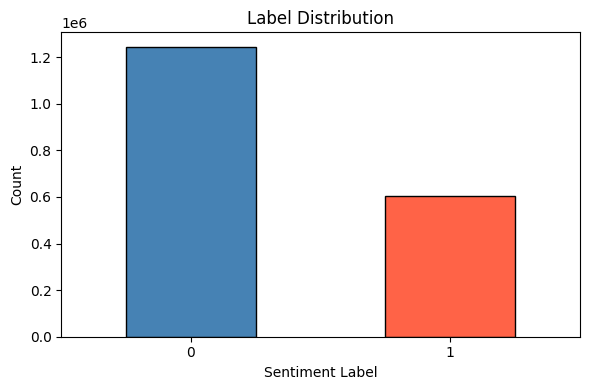

In [9]:
# Basic EDA
print("Label distribution:")
print(df['Sentiment'].value_counts())
print()
print("Missing values:")
print(df.isnull().sum())

# Visualise class balance
df['Sentiment'].value_counts().plot(kind='bar', color=['steelblue', 'tomato', 'seagreen'],
                                     edgecolor='black', figsize=(6, 4))
plt.title('Label Distribution')
plt.xlabel('Sentiment Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Helper Function for Text Cleaning:

Implement a Helper Function as per Text Preprocessing Notebook and Complete the following pipeline.

# Build a Text Cleaning Pipeline

In [10]:
# Initialise tools once (avoids re-creating them per call)
lemmatizer = WordNetLemmatizer()
stemmer    = PorterStemmer()
stop_words = set(stopwords.words('english'))

# Precompile regex patterns for speed
URL_PATTERN   = re.compile(r'https?://\S+|www\.\S+')
EMOJI_PATTERN = re.compile(
    "["
    u"\U0001F600-\U0001F64F"  # emoticons
    u"\U0001F300-\U0001F5FF"  # symbols & pictographs
    u"\U0001F680-\U0001F6FF"  # transport & map
    u"\U0001F1E0-\U0001F1FF"  # flags
    u"\U00002700-\U000027BF"  # dingbats
    u"\U0001FA00-\U0001FA6F"  # chess pieces, etc.
    u"\U0001FA70-\U0001FAFF"  # additional symbols
    u"\U00002702-\U000027B0"
    "]+",
    flags=re.UNICODE
)
CLEAN_PATTERN = re.compile(r'[^a-z\s]')  # keep only lowercase letters and spaces


def text_cleaning_pipeline(text, rule="lemmatize"):
    """
    Clean and normalise a raw tweet string.

    Parameters
    ----------
    text : str
        Raw tweet text.
    rule : str, optional
        Normalisation strategy — 'lemmatize' (default) or 'stem'.

    Returns
    -------
    str
        A single cleaned string ready for vectorisation.
    """
    # 1. Lowercase
    data = str(text).lower()

    # 2. Remove URLs
    data = URL_PATTERN.sub('', data)

    # 3. Remove emojis
    data = EMOJI_PATTERN.sub('', data)

    # 4. Remove all non-alphabetic characters (usernames, hashtags, numbers, punctuation)
    data = CLEAN_PATTERN.sub('', data)

    # 5. Tokenise by whitespace
    tokens = data.split()

    # 6. Remove stopwords
    tokens = [t for t in tokens if t not in stop_words]

    # 7. Lemmatize or Stem
    if rule == "lemmatize":
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    elif rule == "stem":
        tokens = [stemmer.stem(t) for t in tokens]
    else:
        print("Pick between lemmatize or stem")

    return " ".join(tokens)


# --- Quick sanity check ---
sample = "Trump just tweeted: 'Make America Great Again!! 🇺🇸' https://t.co/example #MAGA @user123"
print("Original :", sample)
print("Cleaned  :", text_cleaning_pipeline(sample))

Original : Trump just tweeted: 'Make America Great Again!! 🇺🇸' https://t.co/example #MAGA @user123
Cleaned  : trump tweeted make america great maga user


In [11]:
# Drop rows with missing text or label
df.dropna(subset=['text', 'Sentiment'], inplace=True)
df.reset_index(drop=True, inplace=True)

# Apply cleaning
df['cleaned_text'] = df['text'].apply(lambda x: text_cleaning_pipeline(x, rule='lemmatize'))
df[['text', 'cleaned_text', 'Sentiment']].head(5)

,text,cleaned_text,Sentiment
0,RT @JohnLeguizamo: #trump not draining swamp b...,rt johnleguizamo trump draining swamp taxpayer...,0
1,ICYMI: Hackers Rig FM Radio Stations To Play A...,icymi hacker rig fm radio station play antitru...,0
2,Trump protests: LGBTQ rally in New York https:...,trump protest lgbtq rally new york bbcworld vi...,1
3,"""Hi I'm Piers Morgan. David Beckham is awful b...",hi im pier morgan david beckham awful donald t...,0
4,RT @GlennFranco68: Tech Firm Suing BuzzFeed fo...,rt glennfranco tech firm suing buzzfeed publis...,0


In [13]:
X = df['cleaned_text']
y = df['Sentiment']   # ← was 'label'

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

Training samples : 1480098
Testing  samples : 370025


In [14]:
tfidf = TfidfVectorizer(
    max_features=10_000,   # keep the top 10,000 terms
    ngram_range=(1, 2),    # use unigrams and bigrams
    min_df=2               # ignore very rare terms
)

# Fit on training data only — transform both splits
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"Vocabulary size  : {len(tfidf.vocabulary_)}")
print(f"X_train shape    : {X_train_tfidf.shape}")
print(f"X_test  shape    : {X_test_tfidf.shape}")

Vocabulary size  : 10000
X_train shape    : (1480098, 10000)
X_test  shape    : (370025, 10000)


# Text Classification using Machine Learning Models


### 📝 Instructions: Trump Tweet Sentiment Classification

1. **Load the Dataset**  
   Load the dataset named `"trump_tweet_sentiment_analysis.csv"` using `pandas`. Ensure the dataset contains at least two columns: `"text"` and `"label"`.

2. **Text Cleaning and Tokenization**  
   Apply a text preprocessing pipeline to the `"text"` column. This should include:
   - Lowercasing the text  
   - Removing URLs, mentions, punctuation, and special characters  
   - Removing stopwords  
   - Tokenization (optional: stemming or lemmatization)
   - "Complete the above function"

3. **Train-Test Split**  
   Split the cleaned and tokenized dataset into **training** and **testing** sets using `train_test_split` from `sklearn.model_selection`.

4. **TF-IDF Vectorization**  
   Import and use the `TfidfVectorizer` from `sklearn.feature_extraction.text` to transform the training and testing texts into numerical feature vectors.

5. **Model Training and Evaluation**  
   Import **Logistic Regression** (or any machine learning model of your choice) from `sklearn.linear_model`. Train it on the TF-IDF-embedded training data, then evaluate it using the test set.  
   - Print the **classification report** using `classification_report` from `sklearn.metrics`.


In [15]:
model = LogisticRegression(
    max_iter=1000,
    C=1.0,             # inverse regularisation strength
    solver='lbfgs',
    multi_class='auto',
    random_state=42
)

model.fit(X_train_tfidf, y_train)
print(" Model trained successfully!")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


 Model trained successfully!


In [16]:
y_pred = model.predict(X_test_tfidf)

# Overall accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f} ({acc*100:.2f}%)\n")

# Full classification report
print("Classification Report:")
print("=" * 55)
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9272 (92.72%)

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95    248842
           1       0.91      0.87      0.89    121183

    accuracy                           0.93    370025
   macro avg       0.92      0.91      0.92    370025
weighted avg       0.93      0.93      0.93    370025



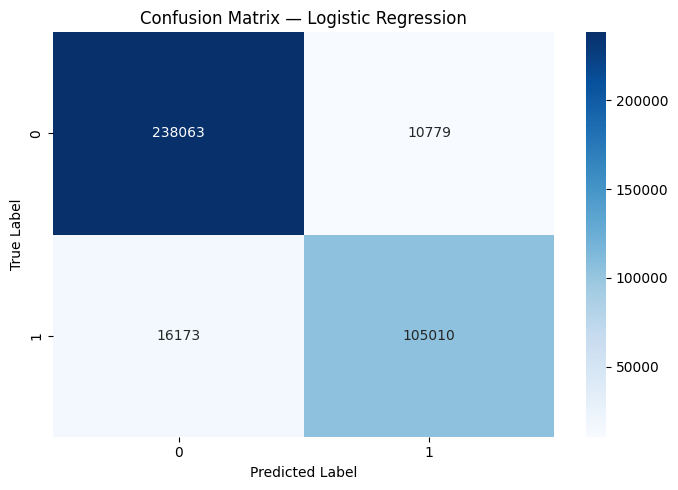

In [17]:
# Confusion Matrix heatmap
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title('Confusion Matrix — Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [18]:
import numpy as np

feature_names = tfidf.get_feature_names_out()
TOP_N = 10

for i, cls in enumerate(model.classes_):
    coef = model.coef_[i] if len(model.classes_) > 2 else model.coef_[0]
    top_idx = np.argsort(coef)[-TOP_N:][::-1]
    top_features = [feature_names[j] for j in top_idx]
    print(f"Class '{cls}' — top {TOP_N} features:")
    print("  ", ", ".join(top_features))
    print()

Class '0' — top 10 features:
   new, please, care, good, well, special, right, love, truth, ready

Class '1' — top 10 features:
   new, please, care, good, well, special, right, love, truth, ready



In [19]:
def predict_sentiment(text, rule='lemmatize'):
    """Clean a custom tweet and return the predicted label."""
    cleaned = text_cleaning_pipeline(text, rule=rule)
    vec     = tfidf.transform([cleaned])
    pred    = model.predict(vec)[0]
    proba   = model.predict_proba(vec)[0]
    print(f"Input    : {text}")
    print(f"Cleaned  : {cleaned}")
    print(f"Predicted: {pred}")
    for cls, p in zip(model.classes_, proba):
        print(f"  P({cls}) = {p:.4f}")
    print()

# Try a few examples
predict_sentiment("The economy is doing great under our leadership!")
predict_sentiment("This is a total disaster. Fake news everywhere.")
predict_sentiment("We will build the wall and make America safe again.")

Input    : The economy is doing great under our leadership!
Cleaned  : economy great leadership
Predicted: 1
  P(0) = 0.0381
  P(1) = 0.9619

Input    : This is a total disaster. Fake news everywhere.
Cleaned  : total disaster fake news everywhere
Predicted: 0
  P(0) = 1.0000
  P(1) = 0.0000

Input    : We will build the wall and make America safe again.
Cleaned  : build wall make america safe
Predicted: 1
  P(0) = 0.0122
  P(1) = 0.9878

